# Multi-Agent Customer Support System
## LangGraph + Claude Haiku 4.5 | Supervisor Pattern

---

### What we will build today

A smart customer support bot that automatically routes customer questions to the right specialist — just like a real support team.

| Tool | Role |
|------|------|
| **LangGraph** | Builds and runs the agent workflow |
| **LangChain** | Common interface to talk to LLMs |
| **Claude Haiku 4.5 (Anthropic)** | The AI brain inside every agent |

### By the end of this session you will understand:
- What multi-agent orchestration means
- What the Supervisor pattern is and why it exists
- How LangGraph nodes, edges, and state work together
- How to build a working multi-agent system from scratch

---
## Concept 1 — What is Multi-Agent Orchestration?

Think of a real company with departments:

```
Customer walks in
      │
      ▼
  Reception
  "Who do you need?"
      │
  ┌───┴───────────┐
  ▼               ▼
Billing        Tech Support
Department     Department
```

A **multi-agent system** works the same way:
- Instead of ONE big AI trying to know everything, we have **multiple focused AI agents**
- Each agent is an expert at one thing
- An **orchestrator** decides who handles each request

### Why not just use one big AI?

| One Big AI | Multi-Agent System |
|------------|-------------------|
| Tries to do everything | Each agent is a specialist |
| System prompts get huge and confused | Clean, focused prompts |
| Hard to update one part | Change one agent without breaking others |
| No visibility into decisions | Can see exactly which agent handled what |

---
## Concept 2 — The Supervisor Pattern

The **Supervisor Pattern** is the most common multi-agent pattern. Here is how it works:

```
                    Customer Message
                          │
                          ▼
                 ┌─────────────────┐
                 │   SUPERVISOR    │  ← reads the message
                 │  decides who    │  ← picks a specialist
                 │  handles this   │
                 └────────┬────────┘
                          │
           ┌──────────────┼──────────────┐
           │              │              │
           ▼              ▼              ▼
    ┌────────────┐  ┌──────────┐  ┌──────────┐
    │  Billing   │  │Technical │  │ General  │
    │   Agent    │  │  Agent   │  │  Agent   │
    └────────────┘  └──────────┘  └──────────┘
           │              │              │
           └──────────────┴──────────────┘
                          │
                          ▼
                      Response
```

### In LangGraph terms:
- Each box is a **Node** (a Python function)
- Each arrow is an **Edge** (a connection)
- The branching arrow from Supervisor is a **Conditional Edge** (dynamic routing)
- All nodes share a **State** (like a shared notebook everyone can read and write)

---
## Step 0 — Install Dependencies

We install three packages:

| Package | Why we need it |
|---------|---------------|
| `langgraph` | Builds the agent graph (nodes + edges) |
| `langchain-core` | Base message types (HumanMessage, AIMessage) |
| `langchain-anthropic` | Connects LangChain to Claude models via Anthropic API |

> The `-q` flag keeps the output quiet — without it you get hundreds of lines.

In [ ]:
!pip install langgraph langchain-core langchain-anthropic -q
print("Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 19.8 MB/s eta 0:00:00
Installation complete!


---
## Step 1 — Anthropic API Key

We use **Claude Haiku 4.5** — Anthropic's fastest and most cost-efficient model. It is perfect for high-volume tasks like routing and support responses.

### How to get your API key (free credits for new accounts):
1. Go to [console.anthropic.com](https://console.anthropic.com) → Sign up
2. Click **API Keys** in the left sidebar
3. Click **Create Key** → give it a name → copy it (starts with `sk-ant-...`)

### Storing the key in Colab (secure way):
- Click the **key icon** in the left sidebar (Secrets)
- Add a new secret named `ANTHROPIC_API_KEY`
- Paste your key as the value

> Never hardcode API keys in notebooks you share — always use Secrets or environment variables.

In [ ]:
import os

# --- Option A: Colab Secrets (recommended — keeps key hidden) ---
try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = ""
    print("API key loaded from Colab Secrets")
except Exception:
    # --- Option B: Paste directly (only for demos, never commit to git) ---
    ANTHROPIC_API_KEY = "sk-ant-YOUR_KEY_HERE"
    print("API key loaded manually")

# Guard: catch missing key early with a clear message
if not ANTHROPIC_API_KEY or ANTHROPIC_API_KEY == "sk-ant-YOUR_KEY_HERE":
    raise ValueError(
        "Anthropic API key not set.\n"
        "In Colab: open Secrets (key icon) → add ANTHROPIC_API_KEY\n"
        "Or replace 'sk-ant-YOUR_KEY_HERE' above with your real key."
    )

# Set as environment variable — LangChain picks this up automatically
os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY
print(f"Key set: sk-ant-...{ANTHROPIC_API_KEY[-4:]}")

API key loaded from Colab Secrets
Key set: sk-ant-...VQAA


---
## Step 2 — Import Libraries

Let us import everything we need and understand what each import does:

| Import | What it gives us |
|--------|------------------|
| `StateGraph` | The graph builder — adds nodes and edges |
| `START, END` | Special markers for the first and last node |
| `HumanMessage` | Wraps the customer's text message |
| `AIMessage` | Wraps the agent's response |
| `SystemMessage` | The hidden instructions we give each agent |
| `TypedDict` | Defines the shape of our shared State |
| `Annotated` | Adds metadata to fields (tells LangGraph HOW to update them) |
| `operator.add` | When updating `messages`, append — don't replace |

In [ ]:
# LangGraph — the orchestration framework
from langgraph.graph import StateGraph, END, START

# LangChain message types — how we structure conversations
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage

# Anthropic / Claude model integration
from langchain_anthropic import ChatAnthropic

# Python typing — used to define our State
from typing import TypedDict, Annotated, List
import operator

print("All imports successful!")

All imports successful!


---
## Step 3 — Initialize the Claude Haiku 4.5 Model

**Claude Haiku 4.5** is Anthropic's fastest model — designed for high-volume, low-latency tasks. It is ideal for routing decisions and concise support replies.

### Why Haiku for this use case?

| Model | Speed | Cost | Best for |
|-------|-------|------|---------|
| Claude Opus | Slower | Higher | Complex reasoning, long documents |
| Claude Sonnet | Balanced | Medium | General tasks, code |
| **Claude Haiku** | **Fastest** | **Lowest** | **Routing, classification, quick replies** |

### Key parameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `model` | `claude-haiku-4-5-20251001` | Exact model version to use |
| `max_tokens` | `256` | Maximum length of the response |
| `temperature` | `0` | `0` = fully deterministic (best for routing decisions) |

In [ ]:
# Initialize Claude Haiku 4.5
# ChatAnthropic handles auth, message formatting, and API calls in one object
chat_llm = ChatAnthropic(
    model="claude-haiku-4-5",
    max_tokens=256,
    temperature=0,   # 0 = deterministic — critical for reliable routing
)

# Quick smoke test
test_response = chat_llm.invoke([HumanMessage(content="Say hello in one word.")])
print(f"Model response: {test_response.content}")
print("Claude Haiku 4.5 is ready!")

Model response: Hello.
Claude Haiku 4.5 is ready!


---
## Step 4 — Define the Shared State

The **State** is the most important concept in LangGraph.

> Think of it as a **shared notebook** that every agent can read and write to.
>
> When one agent finishes, it updates the notebook. The next agent picks up where the last one left off.

Our state has two fields:

### `messages` — the conversation history
```python
messages: Annotated[List[BaseMessage], operator.add]
#                                      ^^^^^^^^^^^^
#                    This tells LangGraph: when updating, ADD to the list
#                    (don't replace it). So every agent appends its reply.
```

### `next_agent` — the routing decision
```python
next_agent: str
#           ^^^
#           The supervisor writes one of:
#           "billing_agent" | "technical_agent" | "general_agent"
```

### How the state evolves step by step:
```
Start:      messages=[HumanMessage("I was double charged")],   next_agent=""
            ↓
Supervisor: messages=[HumanMessage(...)],                       next_agent="billing_agent"
            ↓
Billing:    messages=[HumanMessage(...), AIMessage("I can help with that...")], next_agent="billing_agent"
```

In [ ]:
class CustomerSupportState(TypedDict):
    # Full conversation history — every agent appends to this
    messages: Annotated[List[BaseMessage], operator.add]
    # Which agent the supervisor chose to handle this query
    next_agent: str

print("State defined!")
print("  messages  : the conversation history (grows as agents respond)")
print("  next_agent: supervisor's routing decision")

State defined!
  messages  : the conversation history (grows as agents respond)
  next_agent: supervisor's routing decision


---
## Step 5 — Create the Specialist Agents

Each specialist is a **Python function** that:
1. Receives the current **state** (to read the conversation)
2. Has a **system prompt** that defines its role and personality
3. Calls **Claude Haiku** with the system prompt + conversation history
4. Returns a dict with the new message to add to state

```python
def my_agent(state: CustomerSupportState) -> dict:
    system = SystemMessage(content="You are a ... specialist")
    messages = [system] + state["messages"]   # prepend the system prompt
    response = chat_llm.invoke(messages)
    return {"messages": [response]}            # LangGraph will append this
```

We create **3 specialists**:

| Agent | Handles |
|-------|---------|
| `billing_agent` | Payments, invoices, subscriptions, refunds |
| `technical_agent` | Bugs, errors, crashes, installation issues |
| `general_agent` | Product info, policies, general questions |

In [ ]:
# ── Billing Agent ──────────────────────────────────────────────────────────────
def billing_agent(state: CustomerSupportState) -> dict:
    """Handles payment, invoice, subscription, and refund questions."""

    print("  [Billing Agent] Handling request...")

    system_prompt = SystemMessage(content="""You are a billing specialist at TechCorp customer support.
You handle: payment issues, invoices, subscription plans, pricing, and refund requests.
Be professional, empathetic, and give clear actionable solutions.
Keep your reply concise — 2 to 3 sentences maximum.""")

    # Prepend the system prompt to the conversation history
    full_conversation = [system_prompt] + state["messages"]

    # Call Claude Haiku
    response = chat_llm.invoke(full_conversation)

    # Return only the new message — LangGraph will append it to state["messages"]
    return {"messages": [response]}

print("Billing agent defined!")

Billing agent defined!


In [ ]:
# ── Technical Agent ────────────────────────────────────────────────────────────
def technical_agent(state: CustomerSupportState) -> dict:
    """Handles bugs, errors, installation problems, and technical issues."""

    print("  [Technical Agent] Handling request...")

    system_prompt = SystemMessage(content="""You are a technical support specialist at TechCorp.
You handle: software bugs, error messages, installation problems, crashes, and performance issues.
Provide clear step-by-step guidance. Be methodical and patient.
Keep your reply concise — 2 to 3 sentences maximum.""")

    full_conversation = [system_prompt] + state["messages"]
    response = chat_llm.invoke(full_conversation)

    return {"messages": [response]}

print("Technical agent defined!")

Technical agent defined!


In [ ]:
# ── General Agent ──────────────────────────────────────────────────────────────
def general_agent(state: CustomerSupportState) -> dict:
    """Handles product information, policies, and general inquiries."""

    print("  [General Agent] Handling request...")

    system_prompt = SystemMessage(content="""You are a friendly customer support agent at TechCorp.
You handle: product features, company policies, account information, and general questions.
Be warm, helpful, and informative.
Keep your reply concise — 2 to 3 sentences maximum.""")

    full_conversation = [system_prompt] + state["messages"]
    response = chat_llm.invoke(full_conversation)

    return {"messages": [response]}

print("General agent defined!")

General agent defined!


---
## Step 6 — Create the Supervisor

The **Supervisor** is the key to the whole system. It:
1. Reads the customer's message
2. Instructs Claude Haiku to pick one of the three agents
3. Writes the decision into `state["next_agent"]`

### Two functions we need:

**`supervisor_node`** — the node function (runs Claude, makes the decision)

**`route_decision`** — the routing function (reads the decision and tells LangGraph where to go next)

> LangGraph separates these two: the node does the logic, the router reads the result.

### Robust parsing strategy:
We use keyword matching as a safety net — even if Claude adds extra words around its answer, we still extract the right routing decision:
```python
if "billing" in content:     → billing_agent
elif "technical" in content: → technical_agent
else:                        → general_agent  (safe default)
```

> With `temperature=0`, Claude Haiku is very consistent — but the fallback makes our system production-safe.

In [ ]:
# ── Supervisor Node ────────────────────────────────────────────────────────────
def supervisor_node(state: CustomerSupportState) -> dict:
    """Reads the customer message and decides which specialist should handle it."""

    print("\n[Supervisor] Analyzing the request...")

    system_prompt = SystemMessage(content="""You are a customer support supervisor at TechCorp.
Read the customer message below and decide which specialist should handle it.

Your ONLY job is to output ONE of these exact words — nothing else:
  billing_agent   → payment, invoice, subscription, refund, pricing
  technical_agent → bugs, errors, crashes, installation, performance
  general_agent   → product info, policies, general questions

Output only the agent name. Do not explain your choice.""")

    full_conversation = [system_prompt] + state["messages"]
    response = chat_llm.invoke(full_conversation)

    # Robust parsing — works even if Claude adds extra words around the answer
    content = response.content.strip().lower()

    if "billing" in content:
        next_agent = "billing_agent"
    elif "technical" in content or "tech" in content:
        next_agent = "technical_agent"
    else:
        next_agent = "general_agent"  # safe default

    print(f"[Supervisor] Routing to: {next_agent}")
    return {"next_agent": next_agent}


# ── Routing Function ───────────────────────────────────────────────────────────
def route_decision(state: CustomerSupportState) -> str:
    """Tells LangGraph which node to visit next.
    LangGraph calls this after supervisor_node runs and uses the return value
    to look up the next node in the conditional edges map.
    """
    return state["next_agent"]


print("Supervisor node and routing function defined!")

Supervisor node and routing function defined!


---
## Step 7 — Build the Graph

Now we wire everything together. Think of this as **drawing the flowchart**.

### Three things to do:

**1. Add nodes** — register each function as a node
```python
workflow.add_node("name", function)
```

**2. Add regular edges** — fixed connections (always go here)
```python
workflow.add_edge(START, "supervisor")   # always start at supervisor
workflow.add_edge("billing_agent", END)  # after billing, always end
```

**3. Add conditional edges** — dynamic connections (go here based on a decision)
```python
workflow.add_conditional_edges(
    "supervisor",     # from this node...
    route_decision,   # call this function to get the next node name...
    {                 # use this map to translate the return value:
        "billing_agent":   "billing_agent",
        "technical_agent": "technical_agent",
        "general_agent":   "general_agent",
    }
)
```

### The full flow:
```
START  →  supervisor  →  billing_agent   →  END
                      →  technical_agent →  END
                      →  general_agent   →  END
```

In [ ]:
# Create the graph with our state type
workflow = StateGraph(CustomerSupportState)

# ── Add Nodes ──────────────────────────────────────────────────────────────────
workflow.add_node("supervisor",      supervisor_node)
workflow.add_node("billing_agent",   billing_agent)
workflow.add_node("technical_agent", technical_agent)
workflow.add_node("general_agent",   general_agent)

# ── Add Regular Edges ──────────────────────────────────────────────────────────
workflow.add_edge(START, "supervisor")        # always start at supervisor
workflow.add_edge("billing_agent",   END)     # specialist agents always end
workflow.add_edge("technical_agent", END)
workflow.add_edge("general_agent",   END)

# ── Add Conditional Edges (the dynamic routing) ────────────────────────────────
workflow.add_conditional_edges(
    "supervisor",    # From supervisor...
    route_decision,  # call route_decision(state) to get the next node name
    {
        "billing_agent":   "billing_agent",
        "technical_agent": "technical_agent",
        "general_agent":   "general_agent",
    }
)

# ── Compile ────────────────────────────────────────────────────────────────────
# Compiling validates the graph and prepares it for execution
app = workflow.compile()

print("Graph compiled successfully!")
print()
print("Flow:  START → supervisor → billing_agent   → END")
print("                         → technical_agent → END")
print("                         → general_agent   → END")

Graph compiled successfully!

Flow:  START → supervisor → billing_agent   → END
                         → technical_agent → END
                         → general_agent   → END


---
## Step 8 — Visualize the Graph

LangGraph can generate a diagram of your graph automatically.

This is extremely useful for:
- **Debugging** — see if your edges are wired correctly
- **Communication** — show the architecture to your team
- **Documentation** — understand complex graphs at a glance

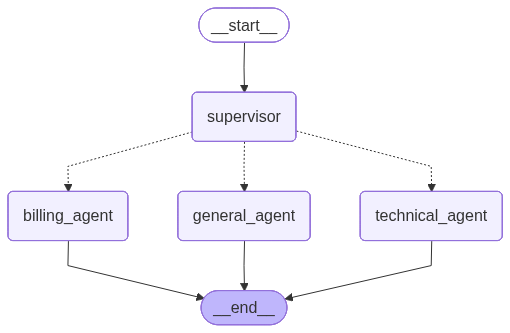

In [ ]:
from IPython.display import Image, display

try:
    # Generates a Mermaid diagram and renders it as a PNG image
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print the Mermaid source (paste at mermaid.live to see it)
    print("Install 'pygraphviz' for image rendering. Mermaid source:")
    print(app.get_graph().draw_mermaid())

---
## Step 9 — Test the System

Time to see it in action!

First, we create a helper function `ask()` that:
1. Takes a customer question as a string
2. Wraps it in a `HumanMessage`
3. Builds the initial state
4. Runs the graph (`app.invoke`)
5. Prints which agent handled it and what it said

Then we test with three different types of questions and watch the supervisor route each one correctly.

In [ ]:
def ask(question: str):
    """Send a customer question through the multi-agent support system."""

    print("=" * 65)
    print(f"Customer: {question}")
    print("=" * 65)

    # Build the initial state — this is what enters the graph
    initial_state = {
        "messages": [HumanMessage(content=question)],
        "next_agent": "",
    }

    # Run the full graph (supervisor → specialist → END)
    result = app.invoke(initial_state)

    # The final AI response is the last message in the history
    final_response = result["messages"][-1].content

    print(f"\nResponse ({result['next_agent']}):\n")
    print(final_response)
    print("=" * 65)
    print()

    return result

print("Helper function ready — let's test!")

Helper function ready — let's test!


In [ ]:
# Test 1: Billing question
# Expected: supervisor → billing_agent
result1 = ask("I was charged twice this month for my subscription. Can you help?")

Customer: I was charged twice this month for my subscription. Can you help?

[Supervisor] Analyzing the request...
[Supervisor] Routing to: billing_agent
  [Billing Agent] Handling request...

Response (billing_agent):

I'm sorry you were charged twice—that's frustrating! I'd be happy to help resolve this. Could you please provide your account email and the dates of both charges so I can investigate and process a refund for the duplicate charge?



In [ ]:
# Test 2: Technical question
# Expected: supervisor → technical_agent
result2 = ask("The app keeps crashing when I try to upload a file. I get a 503 error.")

Customer: The app keeps crashing when I try to upload a file. I get a 503 error.

[Supervisor] Analyzing the request...
[Supervisor] Routing to: technical_agent
  [Technical Agent] Handling request...

Response (technical_agent):

A 503 error means our servers are temporarily unavailable. **First, wait 5-10 minutes and try again.** If it persists, try uploading a smaller file to test, and make sure you're using a supported file format—check our docs for the size and type limits.



In [ ]:
# Test 3: General question
# Expected: supervisor → general_agent
result3 = ask("What features are included in the Pro plan?")

Customer: What features are included in the Pro plan?

[Supervisor] Analyzing the request...
[Supervisor] Routing to: general_agent
  [General Agent] Handling request...

Response (general_agent):

Great question! Our Pro plan includes advanced analytics, priority customer support, up to 5 team members, and unlimited cloud storage. Would you like me to compare it with another plan, or do you have questions about any specific features?



---
## Step 10 — Inspect the State

Let us peek inside the final state object to understand what LangGraph tracked.

The `result` dictionary contains the full state after the graph finished running.

In [ ]:
# Inspect the full state from the last test
print("=== Final State Breakdown ===")
print(f"\nnext_agent: '{result3['next_agent']}'")
print(f"\nTotal messages in history: {len(result3['messages'])}")
print()

for i, msg in enumerate(result3["messages"]):
    role = type(msg).__name__                   # HumanMessage, AIMessage, etc.
    preview = msg.content[:80].replace("\n", " ")
    print(f"  [{i}] {role}: {preview}..." if len(msg.content) > 80 else f"  [{i}] {role}: {msg.content}")

print()
print("Notice: messages[0] = customer question, messages[1] = agent response")

=== Final State Breakdown ===

next_agent: 'general_agent'

Total messages in history: 2

  [0] HumanMessage: What features are included in the Pro plan?
  [1] AIMessage: Great question! Our Pro plan includes advanced analytics, priority customer supp...

Notice: messages[0] = customer question, messages[1] = agent response


---
## Summary — What We Built

Congratulations! You just built a complete multi-agent customer support system.

### Key Concepts Recap

| Concept | What it means | In our code |
|---------|--------------|-------------|
| **Agent** | A function that calls an LLM with a specific role | `billing_agent`, `technical_agent`, `general_agent` |
| **Supervisor** | Decides which agent handles each request | `supervisor_node` |
| **State** | Shared memory that all agents read/write | `CustomerSupportState` |
| **Node** | A registered function in the graph | `add_node("name", fn)` |
| **Edge** | A fixed connection between nodes | `add_edge(A, B)` |
| **Conditional Edge** | A dynamic connection based on a decision | `add_conditional_edges(...)` |
| **Compile** | Validates and locks the graph for execution | `workflow.compile()` |

### The flow we built:
```
Customer message
      │
  [supervisor]  ← reads message, picks specialist
      │
      ├── billing_agent   ← handles payment/refund questions
      ├── technical_agent ← handles bug/error questions
      └── general_agent   ← handles everything else
```

### Ideas to extend this system:

1. **Add more specialists** — e.g. `returns_agent`, `escalation_agent`
2. **Loop back to supervisor** — let the supervisor review the specialist's answer before sending
3. **Add memory** — so agents remember what was said earlier in the conversation
4. **Add tools** — let agents look up orders, query a database, or send emails
5. **Connect a real UI** — hook this up to Slack, WhatsApp, or a web chat widget